# Semana 12: SVD, PCA y reconstrucción

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [2]:
digits = load_digits()
X = digits.data.astype(float)
y = digits.target
X.shape

(1797, 64)

In [3]:
def center_data(X):
    mean = X.mean(axis=0)
    return X - mean, mean

Xc, mean = center_data(X)
print(np.round(Xc.mean(axis=0)[:5], 6))

[ 0. -0.  0.  0.  0.]


In [4]:
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
explained = S**2 / np.sum(S**2)
print(explained[:10])
print(explained[:30].sum())

[0.14890594 0.13618771 0.11794594 0.08409979 0.05782415 0.0491691
 0.04315987 0.03661373 0.03353248 0.03078806]
0.9590854042457171


In [5]:
k = 2
components = Vt[:k]
scores = Xc @ components.T
print(scores.shape)

(1797, 2)


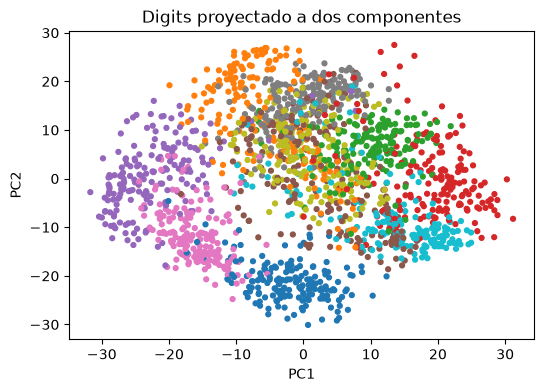

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
scatter = ax.scatter(scores[:, 0], scores[:, 1], c=y, s=12, cmap="tab10")
ax.set_title("Digits proyectado a dos componentes")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.close(fig)
fig

In [7]:
def reconstruct(k):
    components = Vt[:k]
    scores = Xc @ components.T
    X_hat = scores @ components + mean
    mse = np.mean((X - X_hat) ** 2)
    return X_hat, mse

for k in [2, 10, 30, 64]:
    _, mse = reconstruct(k)
    print(k, round(mse, 4), round(explained[:k].sum(), 4))

2 13.421 0.2851
10 4.9143 0.7382
30 0.7681 0.9591
64 0.0 1.0


## Cierre

Reporte $k$, varianza acumulada, error de reconstrucción y una limitación específica.

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30).fit(X)
X_hat_sklearn = pca.inverse_transform(pca.transform(X))
_, mse_manual = reconstruct(30)
{
    "mse_manual": mse_manual,
    "mse_sklearn": float(np.mean((X - X_hat_sklearn) ** 2)),
    "evr_30": float(pca.explained_variance_ratio_.sum()),
}

{'mse_manual': 0.7680940132274643,
 'mse_sklearn': 0.7680940132274643,
 'evr_30': 0.9590854042457174}